In [7]:
import pandas as pd

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "../../")

from spec.enums import MainTableColumns as Cols

In [35]:
# base_dir = '../../../sample_data/cwo/s19/analysis/'
# base_dir = '../../../sample_data/cwo/f19/analysis/'
base_dir = '../../../sample_data/codebench/2024/analysis/'
# base_dir = '../../../sample_data/edwards/2021/analysis/'

In [36]:
data = pd.read_csv(os.path.join(base_dir, 'subject_features.csv'))

In [84]:
data.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,Student1,-0.807513,-0.614539,-0.732036,0.0,-0.026953,0.263161,0.468176,0.124724,0.202407,...,1.006570,1.006570,0.241933,-3.176562e-01,-2.811479e-01,-0.842852,-1.220241,1.204252,0.737199,97.70
1,Student10,-0.580125,-0.833573,-0.719853,0.0,-0.223374,-0.940392,0.468136,-2.329907,0.202407,...,0.952420,0.952420,0.241933,-3.176562e-01,-2.811479e-01,-0.345321,-1.220241,1.204252,0.737199,97.60
2,Student11,-0.759273,-0.773528,-0.804990,0.0,-0.281783,0.249234,-2.452969,-0.881448,-5.900273,...,-1.342380,-1.342380,-4.819365,-2.304225e-17,-1.728168e-17,-0.173592,-0.609330,-0.565005,-1.017049,89.58
3,Student12,1.453097,2.905374,2.227353,0.0,3.352526,-0.632104,0.468189,0.438420,0.202407,...,0.334963,0.334963,0.241933,7.958214e-01,4.498366e+00,3.280841,1.158605,-1.223470,0.737199,95.73
4,Student13,-0.903219,0.048617,-0.453874,0.0,-0.214205,-0.044902,0.577466,-2.272566,0.194724,...,0.089230,0.089230,0.114747,-2.304225e-17,-1.728168e-17,-0.500501,-0.609330,-0.565005,-1.017049,94.52


In [3]:
def load_dataset(base_dir):
    data = pd.read_csv(os.path.join(base_dir, 'subject_features.csv'))
    # There's just one CS course with 18 students, so I don't think it's
    # worth treating as a separate prediction.
    if "X-ClassID" in data.columns:
        data = data[data["X-ClassID"] != 2607741091]
    return data

In [4]:
def get_grade_correlations(data):
    grouping_cols = ["X-ClassID", Cols.SubjectID]
    grouping_cols = [col for col in grouping_cols if col in data.columns]
    corrs = data.drop(columns=grouping_cols).corr(method="spearman")["Grade"].reset_index()
    corrs.rename(columns={"index": "Feature", "Grade": "Rho"}, inplace=True)
    corrs = corrs[corrs["Feature"] != "Grade"]  # Exclude self-correlation
    # corrs["rho_abs"] = corrs["rho"].abs()
    return corrs

In [15]:
all_dirs = {
    'Ed_2021': '../../../sample_data/edwards/2021/analysis/',
    'CWO_S19': '../../../sample_data/cwo/s19/analysis/',
    'CWO_F19': '../../../sample_data/cwo/f19/analysis/',
    'CB_2024': '../../../sample_data/codebench/2024/analysis/',
    'CS1_Eng': '../../../sample_data/CSC111/analysis/',
    'Fal_F21': '../../../sample_data/falconcode/f21/analysis/',
}

In [16]:
all_data = None
for name, dir in all_dirs.items():
    data = load_dataset(dir)
    corrs = get_grade_correlations(data)
    corrs["Dataset"] = name
    if all_data is None:
        all_data = corrs
    else:
        all_data = pd.concat([all_data, corrs], ignore_index=True)
# all_data.sort_values(by="Feature", inplace=True)
all_data["Feature"] = pd.Categorical(all_data["Feature"], categories=all_data["Feature"].unique(), ordered=True)
all_data = all_data[all_data["Feature"].str.endswith("_mean")]
all_data

,Feature,Rho,Dataset
0,ActiveTime_mean,-0.045122,Ed_2021
1,PassiveTime_mean,0.058362,Ed_2021
2,TotalTime_mean,0.010105,Ed_2021
3,ActiveTimeAfterCorrect_mean,NaN,Ed_2021
4,#Breaks_mean,0.287643,Ed_2021
...,...,...,...
201,MeanScore_mean,0.570017,Fal_F21
202,TotalAttempts_mean,-0.458081,Fal_F21
203,AtLeatMedianActiveTime_mean,-0.135886,Fal_F21
204,AtLeatMedianMaxScore_mean,0.490635,Fal_F21


<Axes: xlabel='Dataset', ylabel='Feature'>

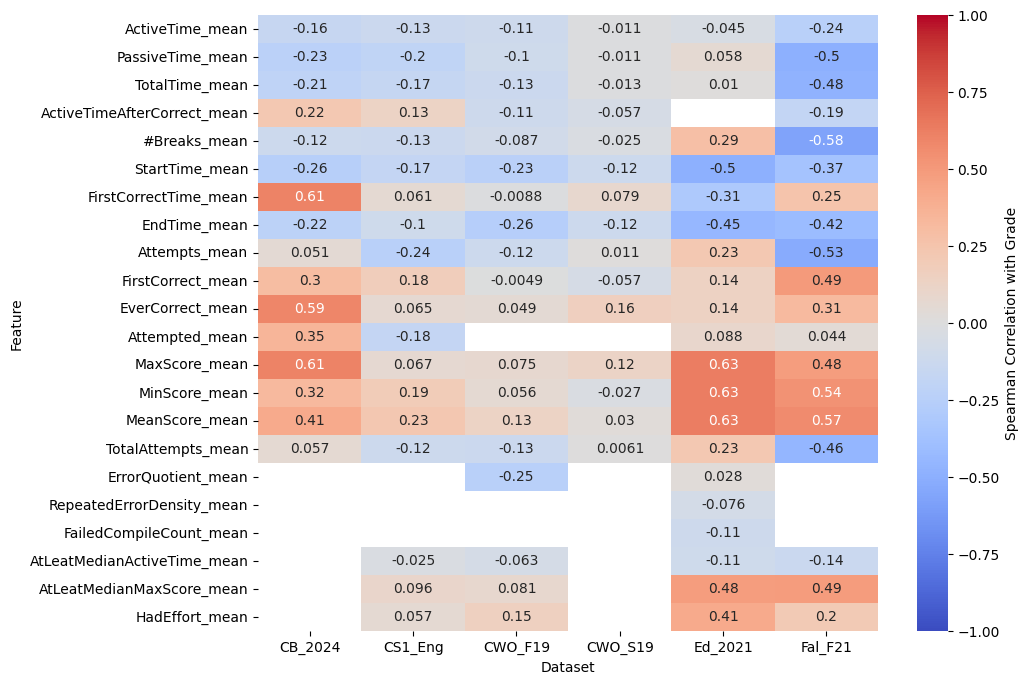

In [ ]:
import seaborn as sns

# TODO: Show significance

plt.figure(figsize=(10, 8))
sns.heatmap(data=all_data.pivot(index="Feature", columns="Dataset", values="Rho"),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    cbar_kws={"label": "Spearman Correlation with Grade"},
)

<Axes: xlabel='Rho', ylabel='Feature'>

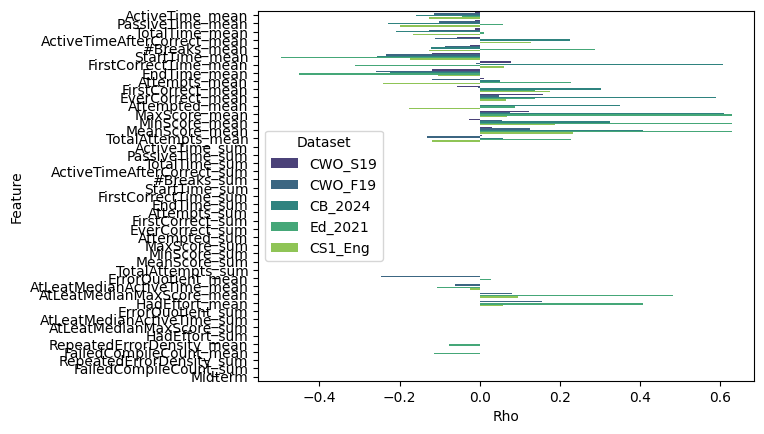

In [10]:
import seaborn as sns

sns.barplot(data=all_data,
    x="Rho",
    y="Feature",
    hue="Dataset",
    dodge=True,
    palette="viridis",
    orient="h",
)

In [39]:
grouping_cols = ["X-ClassID", Cols.SubjectID]
grouping_cols = [col for col in grouping_cols if col in data.columns]

<Axes: >

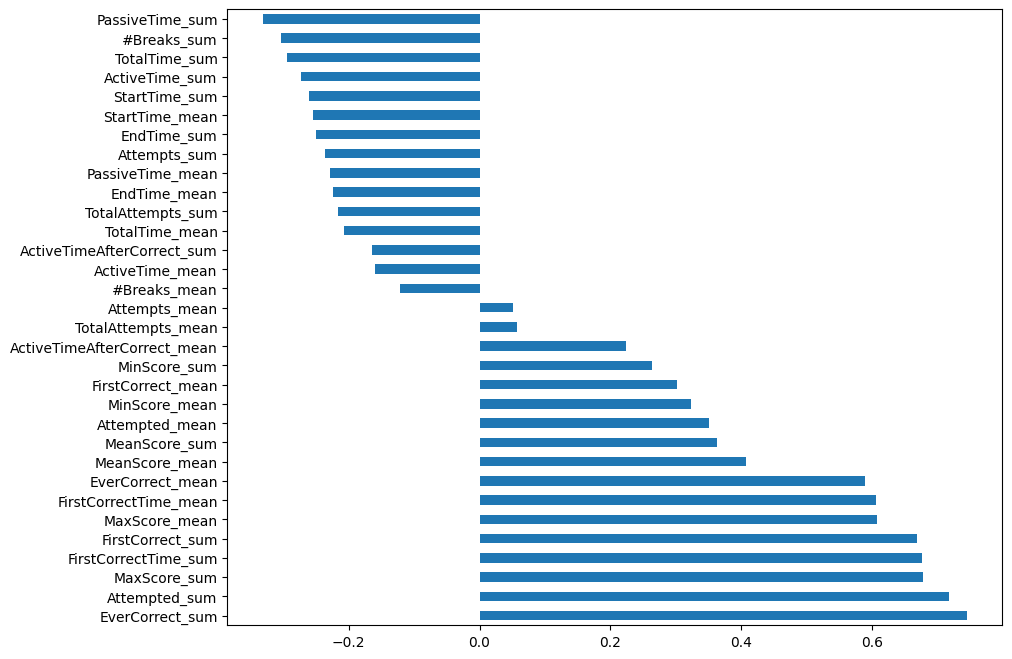

In [40]:
corrs = data.drop(columns=grouping_cols).corr(method="spearman")["Grade"]
corrs = corrs[corrs != 1].sort_values(ascending=False)
corrs.plot(kind='barh', figsize=(10, 8))

In [8]:
X = data.drop(columns=grouping_cols + ['Grade'])
y = data['Grade']

In [9]:
# Drop columns with 0 variance
variance = X.var()
zero_variance_cols = variance[variance == 0].index
print (f"Dropping columns with zero variance: {zero_variance_cols.tolist()}")
X = X.drop(columns=zero_variance_cols)

Dropping columns with zero variance: ['ActiveTimeAfterCorrect_mean', 'ActiveTimeAfterCorrect_sum']


In [10]:
linear_corr = X.corr()
# Find pairs that have correlation above 0.9
corr_pairs = linear_corr[linear_corr != 1].stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = corr_pairs[abs(corr_pairs['Correlation']) > 0.9].reset_index(drop=True)
print("High correlation pairs:")
with pd.option_context('display.max_rows', None):
    print(high_corr_pairs)

High correlation pairs:
                       Feature1                     Feature2  Correlation
0               ActiveTime_mean               TotalTime_mean     0.965812
1               ActiveTime_mean               ActiveTime_sum     0.977075
2               ActiveTime_mean                TotalTime_sum     0.940585
3              PassiveTime_mean               TotalTime_mean     0.958572
4              PassiveTime_mean              PassiveTime_sum     0.980285
5              PassiveTime_mean                TotalTime_sum     0.942590
6                TotalTime_mean              ActiveTime_mean     0.965812
7                TotalTime_mean             PassiveTime_mean     0.958572
8                TotalTime_mean               ActiveTime_sum     0.947427
9                TotalTime_mean              PassiveTime_sum     0.934878
10               TotalTime_mean                TotalTime_sum     0.978603
11                 #Breaks_mean                  #Breaks_sum     0.978775
12            

<Axes: >

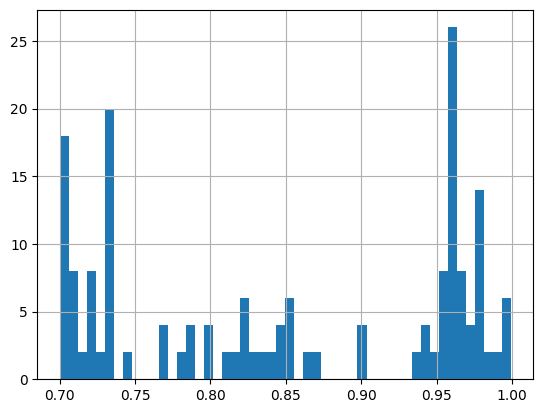

In [11]:
corr_pairs.Correlation[corr_pairs.Correlation > 0.7].hist(bins=50)

In [12]:
# For each highly correlated pair of features, drop the one with the lower
# correlation with the target variable
def drop_low_corr_feature(pair, X, y):
    feature1, feature2 = pair['Feature1'], pair['Feature2']
    corr1 = X[feature1].corr(y)
    corr2 = X[feature2].corr(y)
    if abs(corr1) > abs(corr2):
        return feature2
    else:
        return feature1

to_drop = high_corr_pairs.apply(drop_low_corr_feature, axis=1, X=X, y=y)
print(f"Dropping features with high correlation: {to_drop.tolist()}")
X_lean = X.drop(columns=to_drop)

Dropping features with high correlation: ['ActiveTime_mean', 'ActiveTime_sum', 'TotalTime_sum', 'PassiveTime_mean', 'PassiveTime_sum', 'TotalTime_sum', 'ActiveTime_mean', 'PassiveTime_mean', 'ActiveTime_sum', 'PassiveTime_sum', 'TotalTime_sum', '#Breaks_sum', 'StartTime_sum', 'FirstCorrect_mean', 'EverCorrect_mean', 'FirstCorrectTime_sum', 'EndTime_mean', 'Attempts_mean', 'Attempts_sum', 'TotalAttempts_sum', 'FirstCorrect_mean', 'EverCorrect_mean', 'Attempts_mean', 'TotalAttempts_mean', 'Attempts_sum', 'TotalAttempts_sum', 'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'TotalAttempts_mean', 'Attempts_sum', 'TotalAttempts_sum', 'RepeatedErrorDensity_mean', 'FailedCompileCount_mean', 'AtLeatMedianActiveTime_sum', 'AtLeatMedianMaxScore_sum', 'HadEffort_sum', 'ActiveTime_sum', 'ActiveTime_sum', 'ActiveTime_sum', 'PassiveTime_sum', 'PassiveTime_sum', 'TotalTime_sum', 'TotalTime_sum', 'TotalTi

In [13]:
X_lean.columns

Index(['TotalTime_mean', '#Breaks_mean', 'StartTime_mean',
       'FirstCorrectTime_mean', 'Attempted_mean', 'MaxScore_mean',
       'MinScore_mean', 'MeanScore_mean', 'ErrorQuotient_mean',
       'AtLeatMedianActiveTime_mean', 'AtLeatMedianMaxScore_mean',
       'HadEffort_mean', 'EndTime_sum', 'FirstCorrect_sum', 'EverCorrect_sum',
       'Attempted_sum', 'ErrorQuotient_sum', 'RepeatedErrorDensity_sum',
       'FailedCompileCount_sum'],
      dtype='object')

In [14]:
# Use the original data to peak at Grade
data.drop(columns=to_drop).drop(columns=grouping_cols).corr(method='spearman')

,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,Attempted_mean,MaxScore_mean,MinScore_mean,MeanScore_mean,ErrorQuotient_mean,...,HadEffort_mean,ActiveTimeAfterCorrect_sum,EndTime_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,Grade
TotalTime_mean,1.000000,NaN,0.727732,-0.347213,0.102439,0.156797,0.232299,0.232299,0.232299,-0.108490,...,0.573165,NaN,0.188502,0.271901,0.271901,0.284463,-0.076804,-0.087355,0.558014,0.010105
ActiveTimeAfterCorrect_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
#Breaks_mean,0.727732,NaN,1.000000,-0.602901,-0.022562,-0.017267,0.342272,0.342272,0.342272,-0.076697,...,0.384178,NaN,0.014896,0.254754,0.254754,0.225758,-0.042272,-0.039511,0.368744,0.287643
StartTime_mean,-0.347213,NaN,-0.602901,1.000000,0.322997,0.149331,-0.461807,-0.461807,-0.461807,0.150924,...,-0.377014,NaN,0.513763,-0.206786,-0.206786,-0.055678,0.142060,0.063432,-0.088153,-0.496167
FirstCorrectTime_mean,0.102439,NaN,-0.022562,0.322997,1.000000,0.373327,-0.007674,-0.007674,-0.007674,0.238813,...,-0.090333,NaN,0.434146,0.153989,0.153989,-0.167033,0.267525,0.269678,0.144599,-0.311324
Attempted_mean,0.156797,NaN,-0.017267,0.149331,0.373327,1.000000,0.317193,0.317193,0.317193,-0.091470,...,0.257389,NaN,0.099398,0.412479,0.412479,0.501652,-0.097909,-0.145638,0.120865,0.088198
MaxScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
MinScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
MeanScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
ErrorQuotient_mean,-0.108490,NaN,-0.076697,0.150924,0.238813,-0.091470,-0.208914,-0.208914,-0.208914,1.000000,...,-0.207970,NaN,-0.188431,-0.400091,-0.400091,-0.595279,0.993228,0.818333,0.259974,0.028102


In [15]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.25, random_state=42)

In [16]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    # 'n_estimators': [50, 100, 200, 350, 500],
    'n_estimators': [10, 20, 50, 100, 200],
    'max_depth': [1, 5, 10, 20, 30],
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_absolute_error', return_train_score=True)

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'max_depth': 5, 'n_estimators': 200}


In [17]:
pd.DataFrame(grid_search.cv_results_)[["mean_train_score", "mean_test_score", "std_test_score", "params"]]

,mean_train_score,mean_test_score,std_test_score,params
0,-6.841851,-11.540605,4.224044,"{'max_depth': 1, 'n_estimators': 10}"
1,-6.599704,-11.298883,3.847665,"{'max_depth': 1, 'n_estimators': 20}"
2,-6.494332,-11.312684,3.730622,"{'max_depth': 1, 'n_estimators': 50}"
3,-6.552314,-11.352373,3.727654,"{'max_depth': 1, 'n_estimators': 100}"
4,-6.427500,-11.133114,3.815339,"{'max_depth': 1, 'n_estimators': 200}"
5,-4.146189,-11.231377,4.107577,"{'max_depth': 5, 'n_estimators': 10}"
6,-3.577173,-10.908503,4.044078,"{'max_depth': 5, 'n_estimators': 20}"
7,-3.497982,-10.940448,3.774897,"{'max_depth': 5, 'n_estimators': 50}"
8,-3.710473,-10.837427,3.660293,"{'max_depth': 5, 'n_estimators': 100}"
9,-3.753827,-10.696553,3.730171,"{'max_depth': 5, 'n_estimators': 200}"


<Axes: xlabel='mean_train_score', ylabel='mean_test_score'>

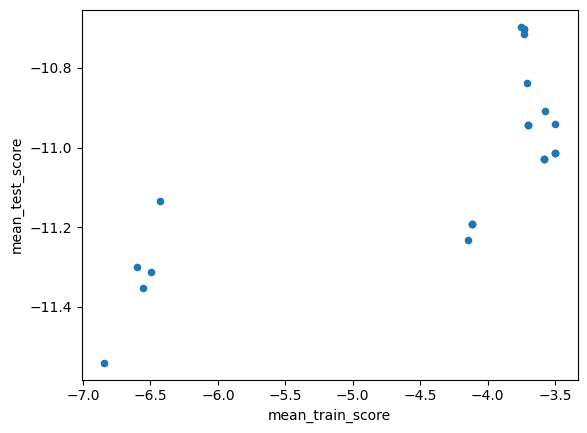

In [18]:
pd.DataFrame(grid_search.cv_results_).plot.scatter("mean_train_score", "mean_test_score")

In [19]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

# Create a table of each feature and its coefficient
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_,
    'Abs_Coefficient': abs(lasso.coef_)
})
lasso_coef.sort_values(by='Abs_Coefficient', ascending=False)


,Feature,Coefficient,Abs_Coefficient
11,HadEffort_mean,7.966799e+00,7.966799e+00
5,MaxScore_mean,1.352861e+00,1.352861e+00
4,Attempted_mean,-1.053030e+00,1.053030e+00
10,AtLeatMedianMaxScore_mean,5.905328e-02,5.905328e-02
6,MinScore_mean,1.072991e-14,1.072991e-14
0,TotalTime_mean,0.000000e+00,0.000000e+00
1,#Breaks_mean,0.000000e+00,0.000000e+00
2,StartTime_mean,-0.000000e+00,0.000000e+00
3,FirstCorrectTime_mean,-0.000000e+00,0.000000e+00
8,ErrorQuotient_mean,0.000000e+00,0.000000e+00


In [20]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
gb_grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='neg_mean_absolute_error')
gb_grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [21]:
pd.DataFrame(gb_grid_search.cv_results_)[["mean_test_score", "std_test_score", "params"]]

,mean_test_score,std_test_score,params
0,-9.740522,3.692831,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
1,-9.830861,3.655241,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
2,-9.768446,3.620371,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
3,-9.828029,3.514749,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
4,-9.723163,3.619472,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
5,-9.910764,3.775390,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
6,-9.844616,3.658429,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
7,-9.942036,3.587417,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
8,-10.314312,3.569140,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
9,-10.346695,3.520657,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

print(mean_absolute_error(y_test, grid_search.predict(X_test)))
print(r2_score(y_test, grid_search.predict(X_test)))

12.52440738577527
-6.830668869258588


In [23]:
print(mean_absolute_error(y_test, lasso.predict(X_test)))
print(r2_score(y_test, lasso.predict(X_test)))

10.900435199452081
-4.1519921563671796


In [24]:
print(mean_absolute_error(y_test, gb_grid_search.predict(X_test)))
print(r2_score(y_test, gb_grid_search.predict(X_test)))

9.511603778705144
-5.777160953194817


In [26]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X_train[['EverCorrect_sum']], y_train)

ever_correct_baseline = linear_reg.predict(X_test[['EverCorrect_sum']])
print(mean_absolute_error(y_test, ever_correct_baseline))
print(r2_score(y_test, ever_correct_baseline))

7.511927710843387
-1.1477574057649993


In [25]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)

print(mean_absolute_error(y_test, dummy_regressor.predict(X_test)))
print(r2_score(y_test, dummy_regressor.predict(X_test)))

5.809545454545468
-0.23218936399607681


<Axes: >

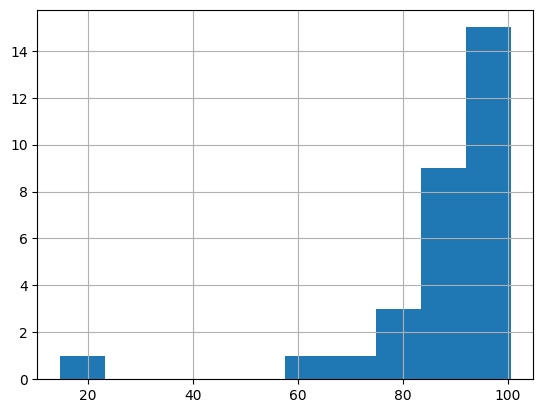

In [27]:
y_train.hist()

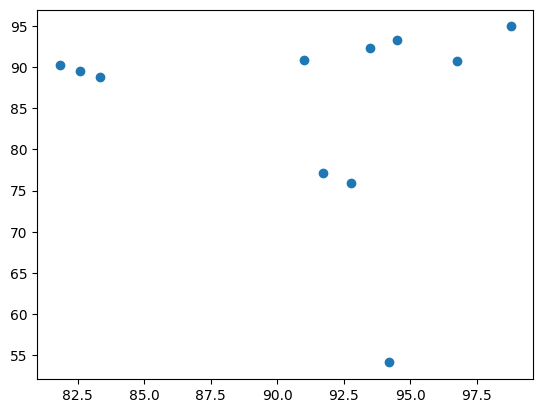

In [28]:
plt.scatter(y_test, gb_grid_search.predict(X_test))

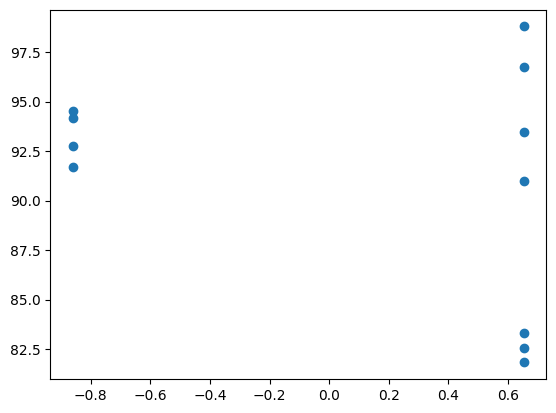

In [29]:
plt.scatter(X_test['EverCorrect_sum'], y_test)